In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

<h2>Preparing the data</h2>

In [3]:
import kagglehub

In [4]:
path = kagglehub.dataset_download("fanbyprinciple/iot-device-identification")

In [5]:
data_train = pd.read_csv(path + "/iot_device_train.csv")
data_test = pd.read_csv(path + "/iot_device_test.csv")

In [6]:
data_all = pd.concat([data_train, data_test], axis=0, ignore_index=True)

In [10]:
data_all = data_all.sample(frac=1, random_state=42).reset_index(drop=True)

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
le = LabelEncoder()
data_all['device_category_label'] = le.fit_transform(data_all['device_category'])

In [39]:
data_all['device_category_label']

0       3
1       0
2       8
3       8
4       4
       ..
1895    2
1896    3
1897    2
1898    5
1899    2
Name: device_category_label, Length: 1900, dtype: int32

In [15]:
data_all.columns

Index(['ack', 'ack_A', 'ack_B', 'bytes', 'bytes_A', 'bytes_A_B_ratio',
       'bytes_B', 'ds_field_A', 'ds_field_B', 'duration',
       ...
       'suffix_is_com', 'suffix_is_com.sg', 'suffix_is_else',
       'suffix_is_empty_char_value', 'suffix_is_googleapis.com',
       'suffix_is_net', 'suffix_is_org', 'suffix_is_unresolved',
       'device_category', 'device_category_label'],
      dtype='object', length=299)

In [19]:
corr = data_all.drop(axis=0, columns='device_category').corr().abs()['device_category_label'].sort_values(ascending=False)

In [20]:
print(corr)

device_category_label       1.000000
reset                       0.404447
reset_A                     0.396896
ttl_B_thirdQ                0.345751
ttl_B_median                0.338601
                              ...   
suffix_is_co.il                  NaN
suffix_is_com.sg                 NaN
suffix_is_googleapis.com         NaN
suffix_is_net                    NaN
suffix_is_org                    NaN
Name: device_category_label, Length: 298, dtype: float64


In [43]:
dummies = pd.get_dummies(data_all['device_category'], dtype=int)
print(dummies)

      TV  baby_monitor  lights  motion_sensor  security_camera  \
0      0             0       0              1                0   
1      1             0       0              0                0   
2      0             0       0              0                0   
3      0             0       0              0                0   
4      0             0       0              0                1   
...   ..           ...     ...            ...              ...   
1895   0             0       1              0                0   
1896   0             0       0              1                0   
1897   0             0       1              0                0   
1898   0             0       0              0                0   
1899   0             0       1              0                0   

      smoke_detector  socket  thermostat  watch  water_sensor  
0                  0       0           0      0             0  
1                  0       0           0      0             0  
2              

In [44]:
categories = dummies.columns.tolist()
print(categories)

['TV', 'baby_monitor', 'lights', 'motion_sensor', 'security_camera', 'smoke_detector', 'socket', 'thermostat', 'watch', 'water_sensor']


In [24]:
data_X = data_all.drop(columns=['device_category', 'device_category_label'])
print(data_X)

        ack  ack_A  ack_B    bytes  bytes_A  bytes_A_B_ratio  bytes_B  \
0        48     18     30     1382      654         0.898350      728   
1         9      5      5     1213      743         1.142203      668   
2         9      5      5     1213      743         1.806874      668   
3         9      5      5     1213      743         1.806874      668   
4        12      6      6     1548      645         0.714285      903   
...     ...    ...    ...      ...      ...              ...      ...   
1895      0      0      0      240        0         0.000000      240   
1896  24718  12359  12359  1483080   741540         1.000000   741540   
1897      0      0      0      240        0         0.000000      240   
1898     14      7      7     2411     1317         1.203838     1094   
1899      0      0      0      240        0         0.000000      240   

      ds_field_A  ds_field_B    duration  ...  suffix_is_cloudfront.net  \
0              0           0      1.7060  ...   

In [45]:
corr_per_category = []
for category in categories:
    corr_per_category.append(pd.concat([data_X, dummies[category]], axis=1).corr().abs()[category].sort_values(ascending=False))

In [47]:
print(corr_per_category[2])

lights                         1.000000
packet_inter_arrivel_min       0.581965
B_port_is_8080                 0.577076
packet_inter_arrivel_firstQ    0.575378
ttl_min                        0.574552
                                 ...   
suffix_is_co.il                     NaN
suffix_is_com.sg                    NaN
suffix_is_googleapis.com            NaN
suffix_is_net                       NaN
suffix_is_org                       NaN
Name: lights, Length: 298, dtype: float64


In [48]:
corr_per_category_top = [corr_per_category[i].head(10) for i in range(len(corr_per_category))]
print(corr_per_category_top)

[TV              1.000000
ttl_B_min       0.496075
reset_B         0.370424
ttl_A_avg       0.308538
ttl_A_firstQ    0.308538
ttl_A_max       0.308538
ttl_A_median    0.308538
ttl_A_min       0.308538
ttl_A_thirdQ    0.308538
ttl_B_median    0.287217
Name: TV, dtype: float64, baby_monitor             1.000000
reset_A                  0.660903
reset                    0.565487
ttl_B_stdev              0.517958
ttl_B_max                0.482812
ttl_B_thirdQ             0.469859
ttl_B_avg                0.434098
ttl_B_firstQ             0.424674
ttl_B_median             0.421507
packet_size_B_entropy    0.404990
Name: baby_monitor, dtype: float64, lights                         1.000000
packet_inter_arrivel_min       0.581965
B_port_is_8080                 0.577076
packet_inter_arrivel_firstQ    0.575378
ttl_min                        0.574552
ttl_firstQ                     0.573342
ds_field_B                     0.572415
packet_inter_arrivel_A_min     0.561040
packet_inter_arrivel_median

C:\Users\randr\AppData\Local\Temp\ipykernel_17380\2759591864.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust layout to make room for the suptitle


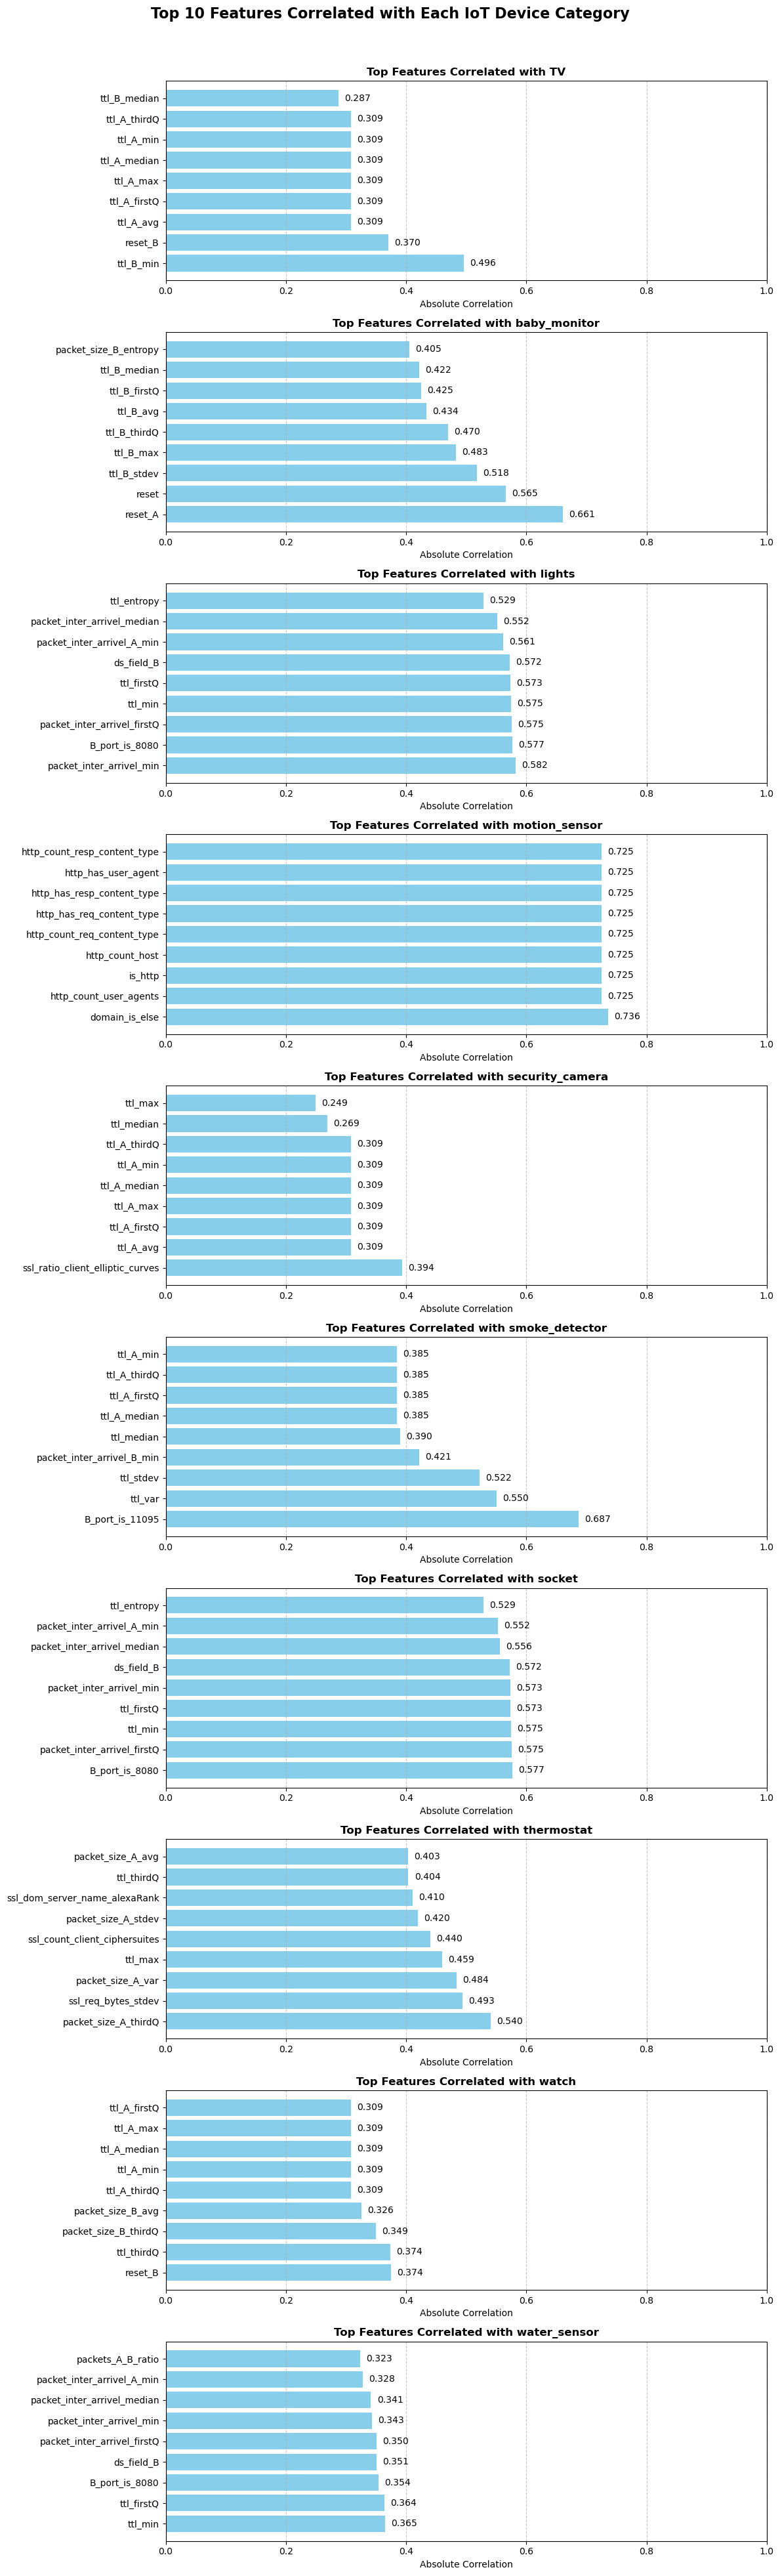

In [49]:
# Create a figure with subplots - one for each device category
fig, axes = plt.subplots(nrows=len(categories), figsize=(12, len(categories)*4), constrained_layout=True)

# Loop through each category and create a bar plot
for i, category in enumerate(categories):
    # Get top correlations for this category
    top_corr = corr_per_category_top[i]
    
    # Remove the self-correlation (which will always be 1.0)
    if category in top_corr.index:
        top_corr = top_corr.drop(category)
    
    # Create horizontal bar plot
    ax = axes[i]
    bars = ax.barh(top_corr.index, top_corr.values, color='skyblue')
    
    # Add value labels to bars
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', va='center')
    
    # Add labels and title
    ax.set_title(f'Top Features Correlated with {category}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Absolute Correlation')
    ax.tick_params(axis='y', labelsize=10)
    
    # Set the x-axis to go from 0 to 1 (correlation range)
    ax.set_xlim(0, 1.0)
    
    # Add grid for better readability
    ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.suptitle('Top 10 Features Correlated with Each IoT Device Category', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust layout to make room for the suptitle
plt.show()

C:\Users\randr\AppData\Local\Temp\ipykernel_17380\1302040088.py:39: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the suptitle


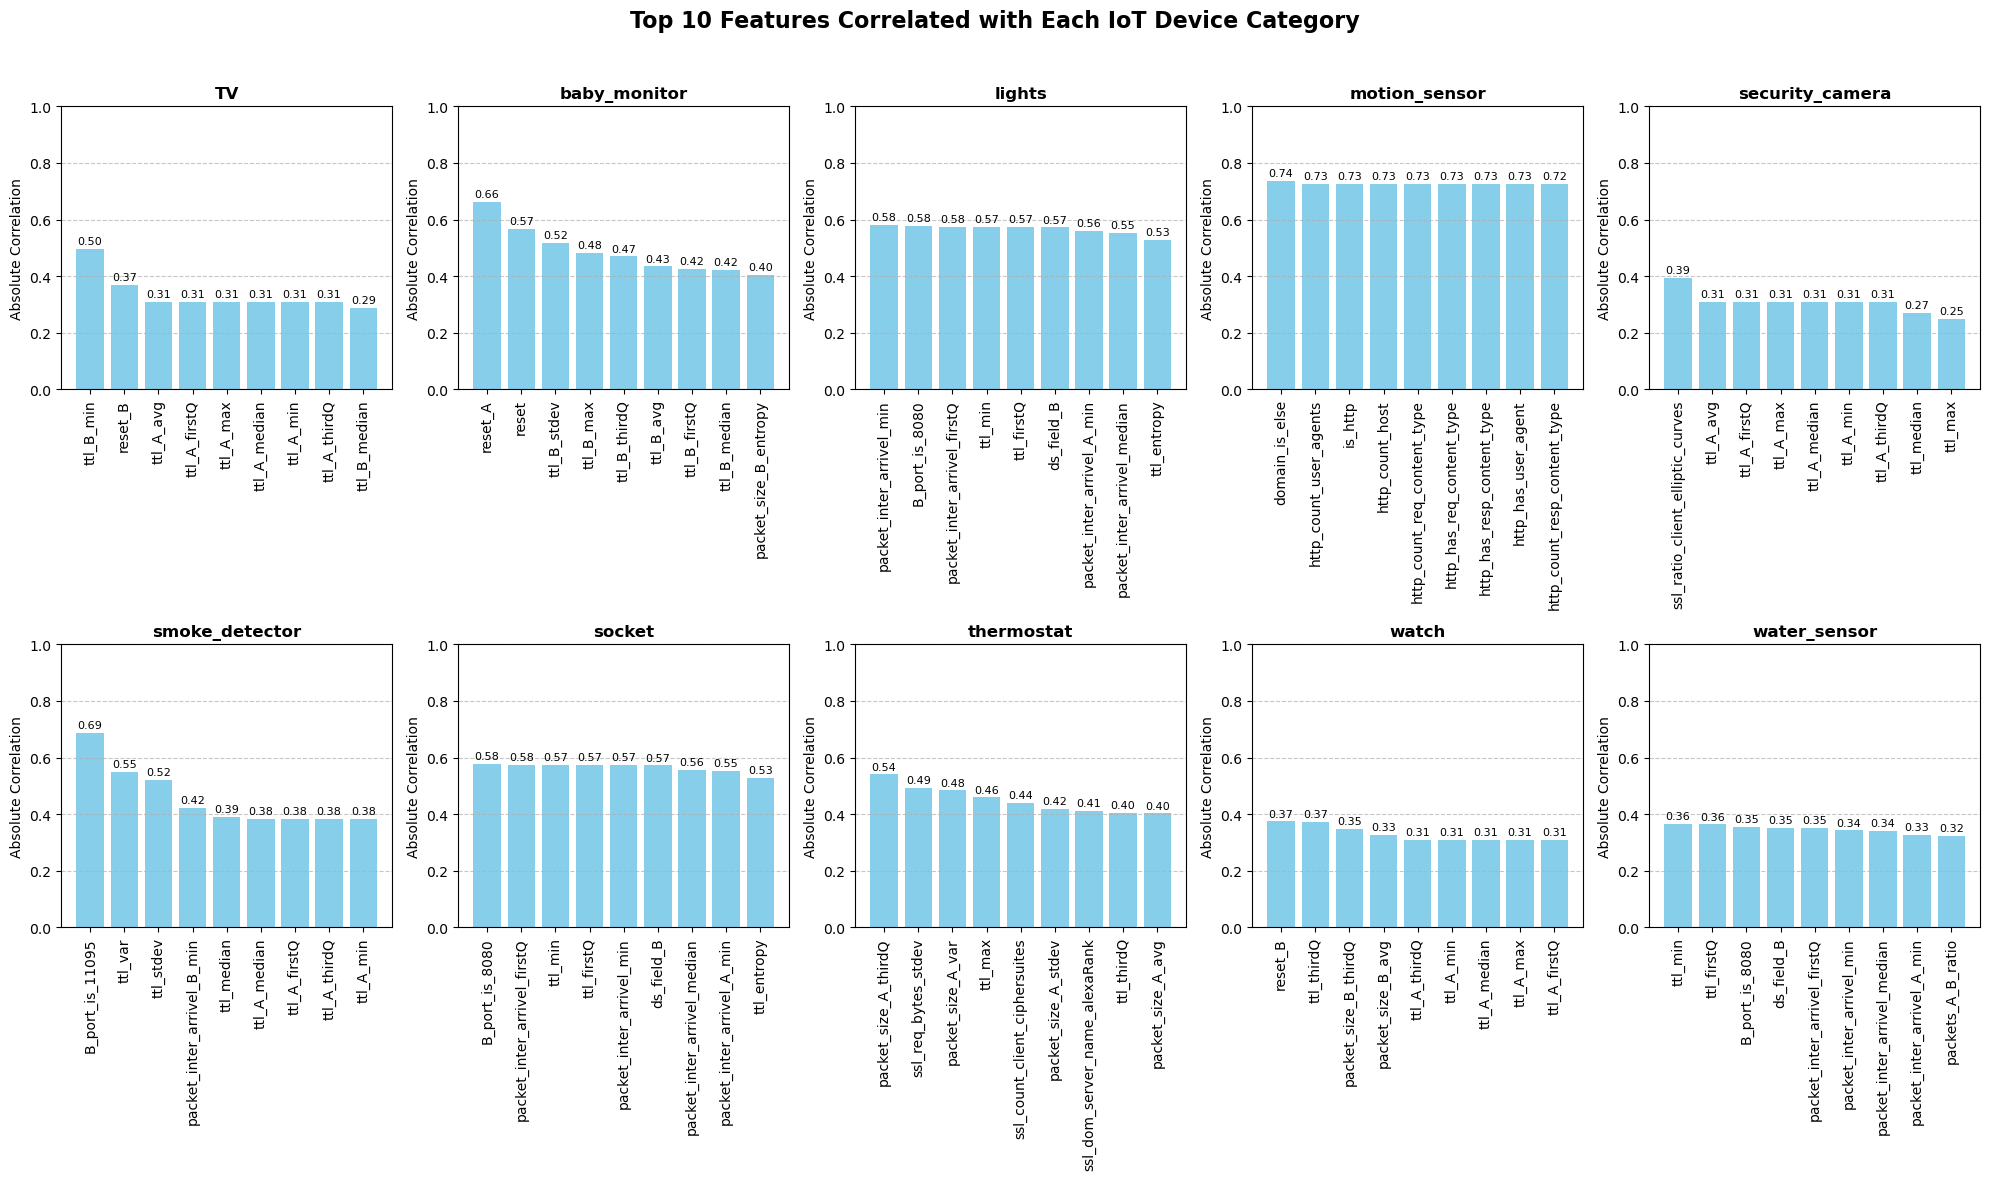

In [50]:
# Create a figure with subplots in a 2x5 grid
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 12), constrained_layout=True)
axes = axes.flatten()  # Flatten the 2D array of axes for easier indexing

# Loop through each category and create a bar plot
for i, category in enumerate(categories):
    # Get top correlations for this category
    top_corr = corr_per_category_top[i]
    
    # Remove the self-correlation (which will always be 1.0)
    if category in top_corr.index:
        top_corr = top_corr.drop(category)
    
    # Create vertical bar plot
    ax = axes[i]
    bars = ax.bar(range(len(top_corr)), top_corr.values, color='skyblue')
    
    # Add x-axis labels with rotation
    ax.set_xticks(range(len(top_corr)))
    ax.set_xticklabels(top_corr.index, rotation=90)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)
    
    # Add labels and title
    ax.set_title(f'{category}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Absolute Correlation')
    
    # Set the y-axis to go from 0 to 1 (correlation range)
    ax.set_ylim(0, 1.0)
    
    # Add grid for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Top 10 Features Correlated with Each IoT Device Category', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the suptitle
plt.show()

C:\Users\randr\AppData\Local\Temp\ipykernel_17380\345962210.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('tab20', len(all_features))
C:\Users\randr\AppData\Local\Temp\ipykernel_17380\345962210.py:58: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the suptitle


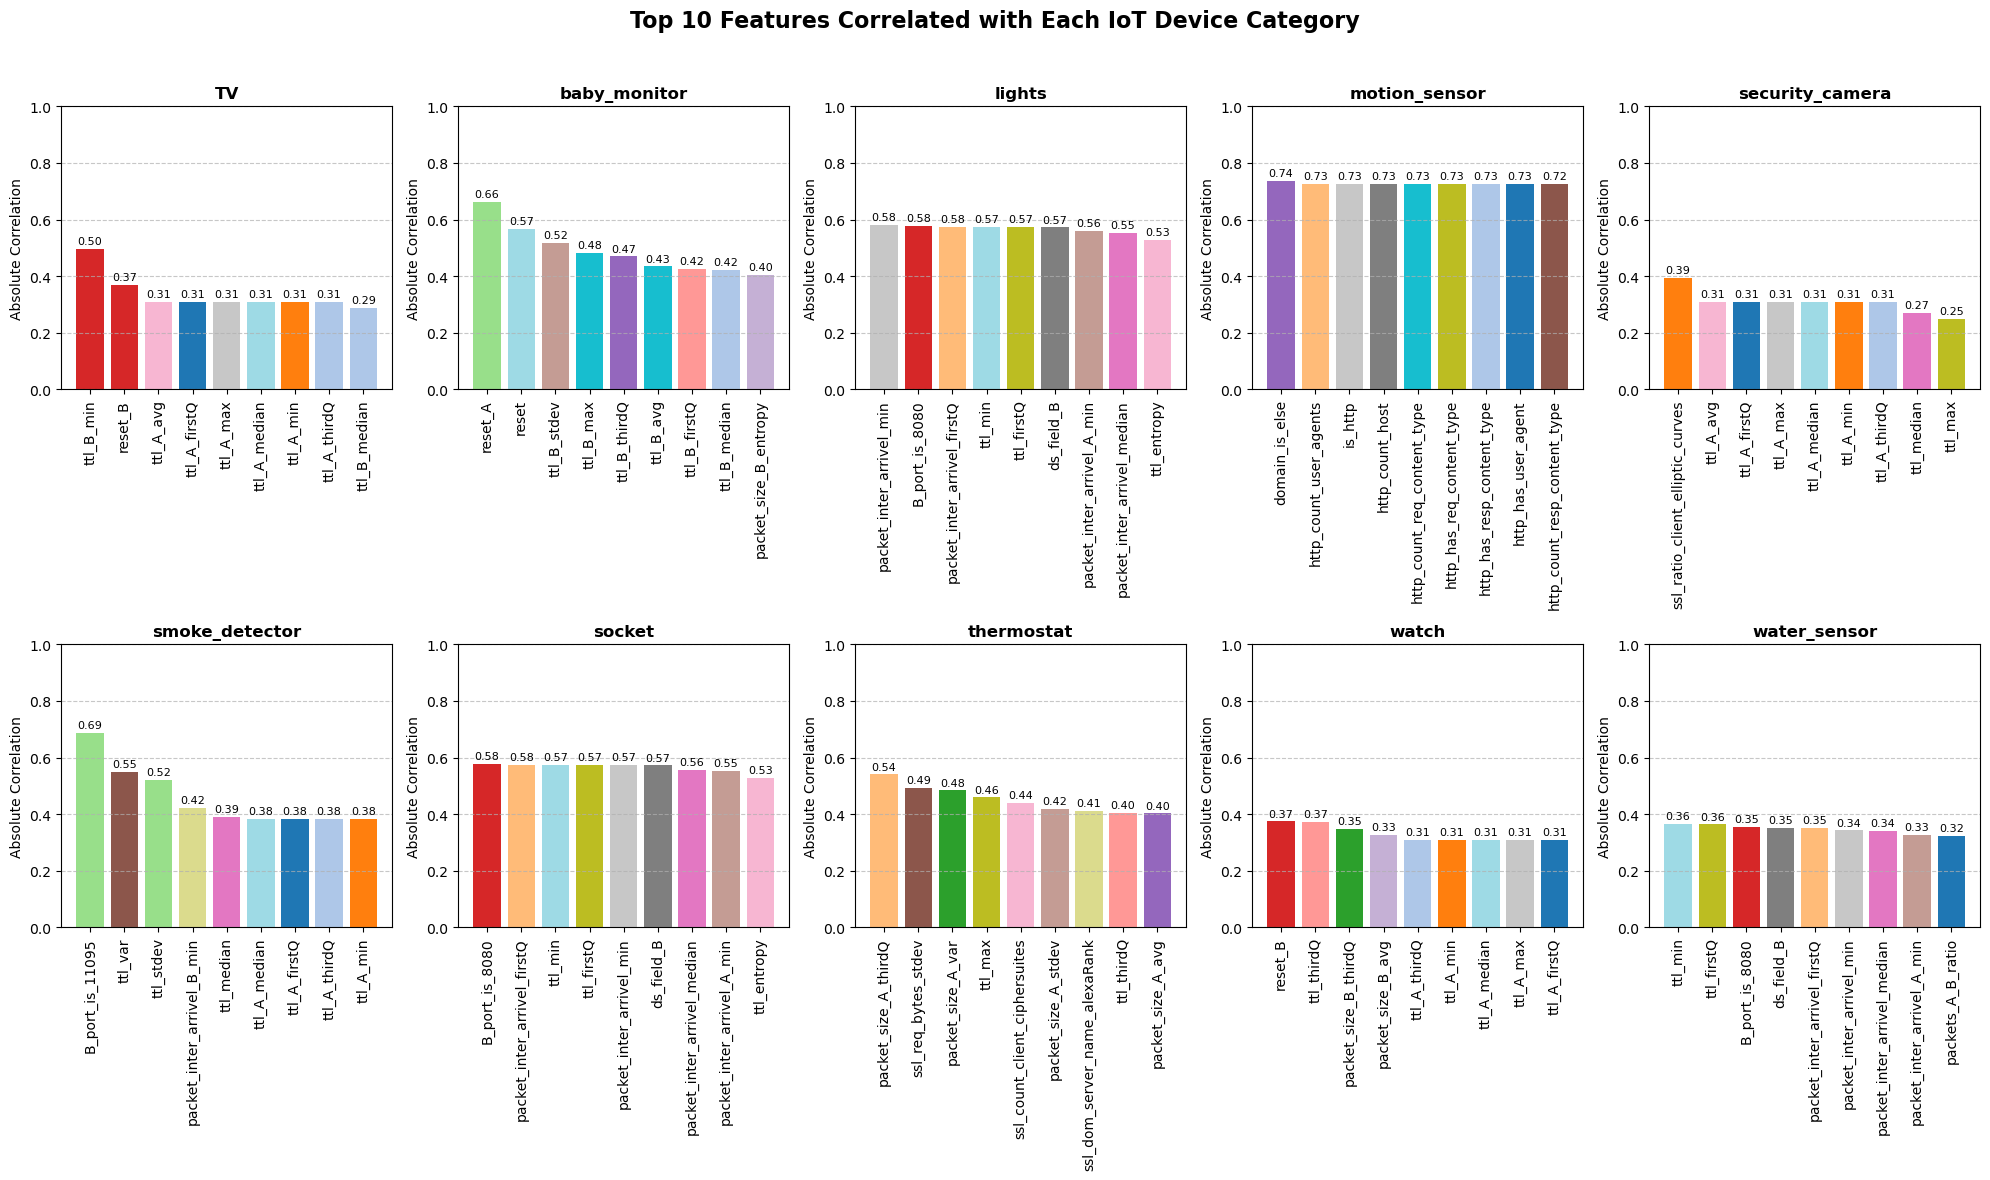

In [ ]:
# Create a figure with subplots in a 2x5 grid
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 12), constrained_layout=True)
axes = axes.flatten()  # Flatten the 2D array of axes for easier indexing

# Get all unique feature names across all categories
features = set()
for i in range(len(categories)):
    top_corr = corr_per_category_top[i]
    if categories[i] in top_corr.index:
        top_corr = top_corr.drop(categories[i])
    features.update(top_corr.index)
features = list(all_features)

# Create a color mapping for all unique features using a colormap
from matplotlib.cm import get_cmap
cmap = get_cmap('tab20', len(all_features))
feature_color_map = {feature: cmap(i) for i, feature in enumerate(all_features)}

# Loop through each category and create a bar plot with distinct colors
for i, category in enumerate(categories):
    # Get top correlations for this category
    top_corr = corr_per_category_top[i]
    
    # Remove the self-correlation (which will always be 1.0)
    if category in top_corr.index:
        top_corr = top_corr.drop(category)
    
    # Create vertical bar plot with distinct colors
    ax = axes[i]
    
    # Get colors for each feature in this category
    colors = [feature_color_map[feature] for feature in top_corr.index]
    
    # Create bars with colors corresponding to each feature
    bars = ax.bar(range(len(top_corr)), top_corr.values, color=colors)
    
    # Add x-axis labels with rotation
    ax.set_xticks(range(len(top_corr)))
    ax.set_xticklabels(top_corr.index, rotation=90)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)
    
    # Add labels and title
    ax.set_title(f'{category}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Absolute Correlation')
    
    # Set the y-axis to go from 0 to 1 (correlation range)
    ax.set_ylim(0, 1.0)
    
    # Add grid for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Top 10 Features Correlated with Each IoT Device Category', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the suptitle
plt.show()

['B_port_is_11095', 'B_port_is_8080', 'domain_is_else', 'ds_field_B', 'http_count_host', 'http_count_req_content_type', 'http_count_resp_content_type', 'http_count_user_agents', 'http_has_req_content_type', 'http_has_resp_content_type', 'http_has_user_agent', 'is_http', 'packet_inter_arrivel_A_min', 'packet_inter_arrivel_B_min', 'packet_inter_arrivel_firstQ', 'packet_inter_arrivel_median', 'packet_inter_arrivel_min', 'packet_size_A_avg', 'packet_size_A_stdev', 'packet_size_A_thirdQ', 'packet_size_A_var', 'packet_size_B_avg', 'packet_size_B_entropy', 'packet_size_B_thirdQ', 'packets_A_B_ratio', 'reset', 'reset_A', 'reset_B', 'ssl_count_client_ciphersuites', 'ssl_dom_server_name_alexaRank', 'ssl_ratio_client_elliptic_curves', 'ssl_req_bytes_stdev', 'ttl_A_avg', 'ttl_A_firstQ', 'ttl_A_max', 'ttl_A_median', 'ttl_A_min', 'ttl_A_thirdQ', 'ttl_B_avg', 'ttl_B_firstQ', 'ttl_B_max', 'ttl_B_median', 'ttl_B_min', 'ttl_B_stdev', 'ttl_B_thirdQ', 'ttl_entropy', 'ttl_firstQ', 'ttl_max', 'ttl_median', 

C:\Users\randr\AppData\Local\Temp\ipykernel_17380\1079312840.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('Set3', len(all_features))
C:\Users\randr\AppData\Local\Temp\ipykernel_17380\1079312840.py:63: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the suptitle


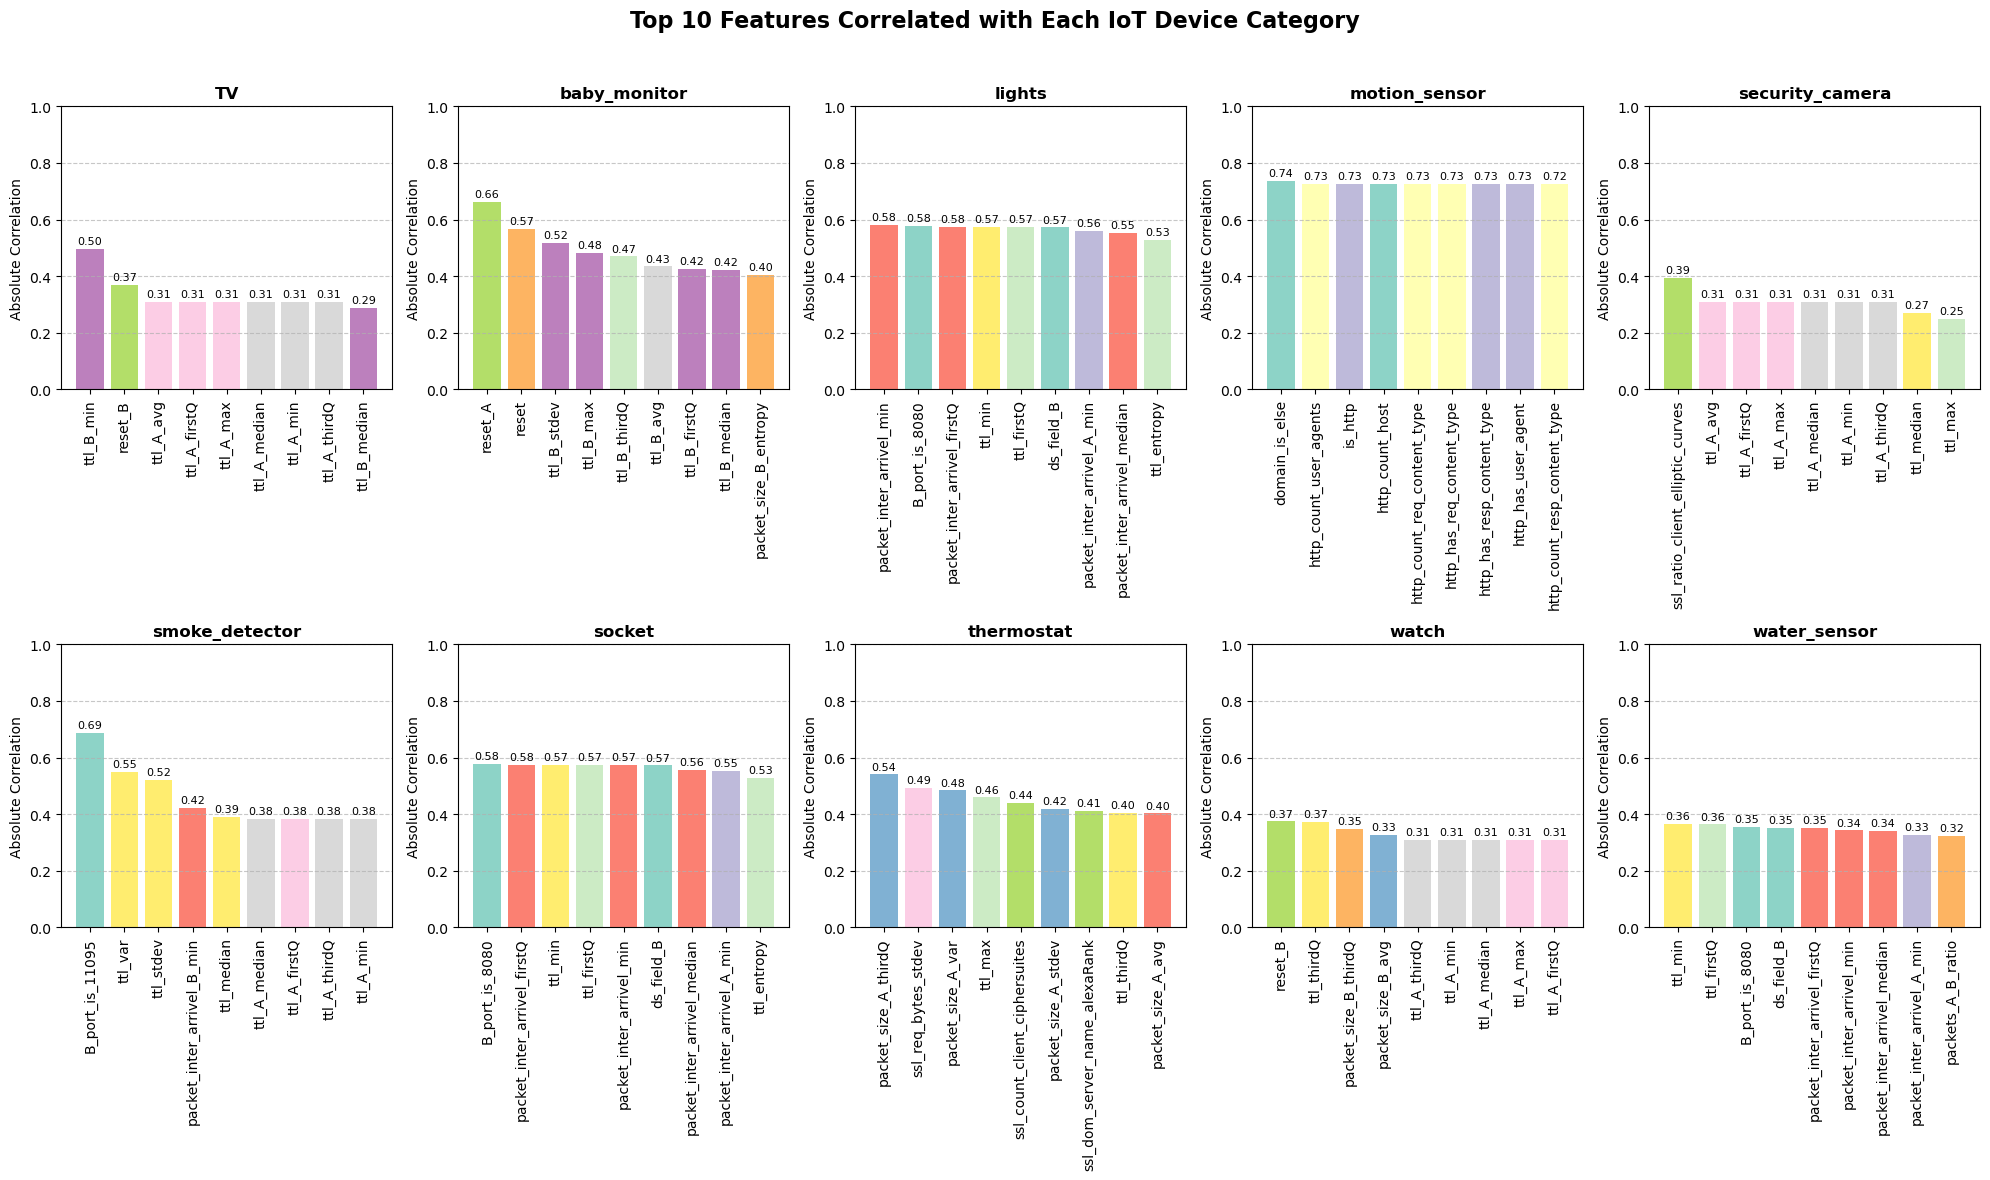

In [ ]:
# Create a figure with subplots in a 2x5 grid
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 12), constrained_layout=True)
axes = axes.flatten()  # Flatten the 2D array of axes for easier indexing

# Create a color mapping for all unique features using a colormap
from matplotlib.cm import get_cmap
#cmap = get_cmap('tab20', len(all_features))
# use a different colormap for better distinction
cmap = get_cmap('Set3', len(all_features))
feature_color_map = {feature: cmap(i) for i, feature in enumerate(all_features)}

# Loop through each category and create a bar plot with distinct colors
for i, category in enumerate(categories):
    # Get top correlations for this category
    top_corr = corr_per_category_top[i]
    
    # Remove the self-correlation (which will always be 1.0)
    if category in top_corr.index:
        top_corr = top_corr.drop(category)
    
    # Create vertical bar plot with distinct colors
    ax = axes[i]
    
    # Get colors for each feature in this category
    colors = [feature_color_map[feature] for feature in top_corr.index]
    
    # Create bars with colors corresponding to each feature
    bars = ax.bar(range(len(top_corr)), top_corr.values, color=colors)
    
    # Add x-axis labels with rotation
    ax.set_xticks(range(len(top_corr)))
    ax.set_xticklabels(top_corr.index, rotation=90)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)
    
    # Add labels and title
    ax.set_title(f'{category}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Absolute Correlation')
    
    # Set the y-axis to go from 0 to 1 (correlation range)
    ax.set_ylim(0, 1.0)
    
    # Add grid for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Top 10 Features Correlated with Each IoT Device Category', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the suptitle
plt.show()

In [ ]:
# Get all unique feature names across all categories
all_features = set()
for i in range(len(categories)):
    top_corr = corr_per_category_top[i]
    if categories[i] in top_corr.index:
        top_corr = top_corr.drop(categories[i])
    all_features.update(top_corr.index)
all_features = list(all_features)
# order elements of all_features alphabetically
all_features.sort()
print(all_features)

['B_port_is_11095', 'B_port_is_8080', 'domain_is_else', 'ds_field_B', 'http_count_host', 'http_count_req_content_type', 'http_count_resp_content_type', 'http_count_user_agents', 'http_has_req_content_type', 'http_has_resp_content_type', 'http_has_user_agent', 'is_http', 'packet_inter_arrivel_A_min', 'packet_inter_arrivel_B_min', 'packet_inter_arrivel_firstQ', 'packet_inter_arrivel_median', 'packet_inter_arrivel_min', 'packet_size_A_avg', 'packet_size_A_stdev', 'packet_size_A_thirdQ', 'packet_size_A_var', 'packet_size_B_avg', 'packet_size_B_entropy', 'packet_size_B_thirdQ', 'packets_A_B_ratio', 'reset', 'reset_A', 'reset_B', 'ssl_count_client_ciphersuites', 'ssl_dom_server_name_alexaRank', 'ssl_ratio_client_elliptic_curves', 'ssl_req_bytes_stdev', 'ttl_A_avg', 'ttl_A_firstQ', 'ttl_A_max', 'ttl_A_median', 'ttl_A_min', 'ttl_A_thirdQ', 'ttl_B_avg', 'ttl_B_firstQ', 'ttl_B_max', 'ttl_B_median', 'ttl_B_min', 'ttl_B_stdev', 'ttl_B_thirdQ', 'ttl_entropy', 'ttl_firstQ', 'ttl_max', 'ttl_median', 

In [ ]:
# create a dictionary with the elements of all_features as keys that contains the number of occurrences of each element in the list corr_per_category_top
all_features_count = {feature: 0 for feature in all_features}
for i in range(len(categories)):
    top_corr = corr_per_category_top[i]
    if categories[i] in top_corr.index:
        top_corr = top_corr.drop(categories[i])
    for feature in top_corr.index:
        all_features_count[feature] += 1
print(all_features_count)

{'B_port_is_11095': 1, 'B_port_is_8080': 3, 'domain_is_else': 1, 'ds_field_B': 3, 'http_count_host': 1, 'http_count_req_content_type': 1, 'http_count_resp_content_type': 1, 'http_count_user_agents': 1, 'http_has_req_content_type': 1, 'http_has_resp_content_type': 1, 'http_has_user_agent': 1, 'is_http': 1, 'packet_inter_arrivel_A_min': 3, 'packet_inter_arrivel_B_min': 1, 'packet_inter_arrivel_firstQ': 3, 'packet_inter_arrivel_median': 3, 'packet_inter_arrivel_min': 3, 'packet_size_A_avg': 1, 'packet_size_A_stdev': 1, 'packet_size_A_thirdQ': 1, 'packet_size_A_var': 1, 'packet_size_B_avg': 1, 'packet_size_B_entropy': 1, 'packet_size_B_thirdQ': 1, 'packets_A_B_ratio': 1, 'reset': 1, 'reset_A': 1, 'reset_B': 2, 'ssl_count_client_ciphersuites': 1, 'ssl_dom_server_name_alexaRank': 1, 'ssl_ratio_client_elliptic_curves': 1, 'ssl_req_bytes_stdev': 1, 'ttl_A_avg': 2, 'ttl_A_firstQ': 4, 'ttl_A_max': 3, 'ttl_A_median': 4, 'ttl_A_min': 4, 'ttl_A_thirdQ': 4, 'ttl_B_avg': 1, 'ttl_B_firstQ': 1, 'ttl_B_

In [ ]:
print(len(all_features))

53


In [ ]:
# put all elements in all_features that start with 'B_port_is' in a new list
all_features_B_port_is = [feature for feature in all_features if feature.startswith('B_port_is')]
print(all_features_B_port_is)

['B_port_is_11095', 'B_port_is_8080']


In [63]:
# B_port features
features_B_port = [feature for feature in all_features if feature.startswith('B_port')]
print("B_port features")
print(features_B_port)
print(len(features_B_port))
# http features
features_http = [feature for feature in all_features if feature.startswith('http')]
features_http.append('is_http')
print("http features")
print(features_http)
print(len(features_http))
# packet_inter features
features_packet_inter = [feature for feature in all_features if feature.startswith('packet_inter')]
print("packet_inter features")
print(features_packet_inter)
print(len(features_packet_inter))
# packet_size features
features_packet_size = [feature for feature in all_features if feature.startswith('packet_size')]
print("packet_size features")
print(features_packet_size)
print(len(features_packet_size))
# reset features
features_reset = [feature for feature in all_features if feature.startswith('reset')]
print("reset features")
print(features_reset)
print(len(features_reset))
# ssl features
features_ssl = [feature for feature in all_features if feature.startswith('ssl')]
print("ssl features")
print(features_ssl)
print(len(features_ssl))
# ttl_A features
features_ttl_A = [feature for feature in all_features if feature.startswith('ttl_A')]
print("ttl_A features")
print(features_ttl_A)
print(len(features_ttl_A))
# ttl_B features
features_ttl_B = [feature for feature in all_features if feature.startswith('ttl_B')]
print("ttl_B features")
print(features_ttl_B)
print(len(features_ttl_B))
# other ttl features
features_ttl_other = [feature for feature in all_features if feature.startswith('ttl_') and feature not in features_ttl_A and feature not in features_ttl_B]
print("other ttl features")
print(features_ttl_other)
print(len(features_ttl_other))
# other features
features_other = [feature for feature in all_features if feature not in features_B_port and feature not in features_http and feature not in features_packet_inter and feature not in features_packet_size and feature not in features_reset and feature not in features_ssl and feature not in features_ttl_A and feature not in features_ttl_B and feature not in features_ttl_other]
print("other features")
print(features_other)
print(len(features_other))

B_port features
['B_port_is_11095', 'B_port_is_8080']
2
http features
['http_count_host', 'http_count_req_content_type', 'http_count_resp_content_type', 'http_count_user_agents', 'http_has_req_content_type', 'http_has_resp_content_type', 'http_has_user_agent', 'is_http']
8
packet_inter features
['packet_inter_arrivel_A_min', 'packet_inter_arrivel_B_min', 'packet_inter_arrivel_firstQ', 'packet_inter_arrivel_median', 'packet_inter_arrivel_min']
5
packet_size features
['packet_size_A_avg', 'packet_size_A_stdev', 'packet_size_A_thirdQ', 'packet_size_A_var', 'packet_size_B_avg', 'packet_size_B_entropy', 'packet_size_B_thirdQ']
7
reset features
['reset', 'reset_A', 'reset_B']
3
ssl features
['ssl_count_client_ciphersuites', 'ssl_dom_server_name_alexaRank', 'ssl_ratio_client_elliptic_curves', 'ssl_req_bytes_stdev']
4
ttl_A features
['ttl_A_avg', 'ttl_A_firstQ', 'ttl_A_max', 'ttl_A_median', 'ttl_A_min', 'ttl_A_thirdQ']
6
ttl_B features
['ttl_B_avg', 'ttl_B_firstQ', 'ttl_B_max', 'ttl_B_median',

In [64]:
# sum the values of all_features_count whose keys correspond to the elements of every list in the previous cell
# and put that sum in a new dictionary with the name of the list as key
feature_sums = {}
for feature_list_name in ['features_B_port', 'features_http', 'features_packet_inter', 'features_packet_size', 
                          'features_reset', 'features_ssl', 'features_ttl_A', 'features_ttl_B', 
                          'features_ttl_other', 'features_other']:
    feature_list = globals()[feature_list_name]
    feature_sums[feature_list_name] = sum(all_features_count[feature] for feature in feature_list)
print(feature_sums)

{'features_B_port': 4, 'features_http': 8, 'features_packet_inter': 13, 'features_packet_size': 7, 'features_reset': 4, 'features_ssl': 4, 'features_ttl_A': 21, 'features_ttl_B': 8, 'features_ttl_other': 16, 'features_other': 5}
